# kNN Model

### We use a kNN model which is a supervised learning classifier that uses proximity to make classifications. An observation is classified based on those around it.  

In [2]:
# kNN model here
# test out diff hyperparameters like k, distance metric, weights
# try out diff distance metrics to do 

import pandas as pd 
import joblib

X_train = pd.read_csv('../data/X_train_scaled.csv')
X_test = pd.read_csv('../data/X_test_scaled.csv')
Y_train = pd.read_csv('../data/Y_train.csv') 
Y_test = pd.read_csv('../data/Y_test.csv')

# since these are loaded as DataFrames convert into 1D arrays 
y_train = Y_train.squeeze()
y_test = Y_test.squeeze()

# we will also load in our label encoder
label_encoder = joblib.load(
    '../data/label_encoder.pkl'
)

Now we'll train a baseline model with k = 5

In [3]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

### Metrics and Visualization
And let's get some metrics...
We'll use macro because we have multiple genres that aren't perfectly balanced and macro averaging treats them all equaly

Accuracy: 0.434971098265896
Precision: 0.42951198622328224
Recall: 0.42298731301713427
F1: 0.4189112897011537


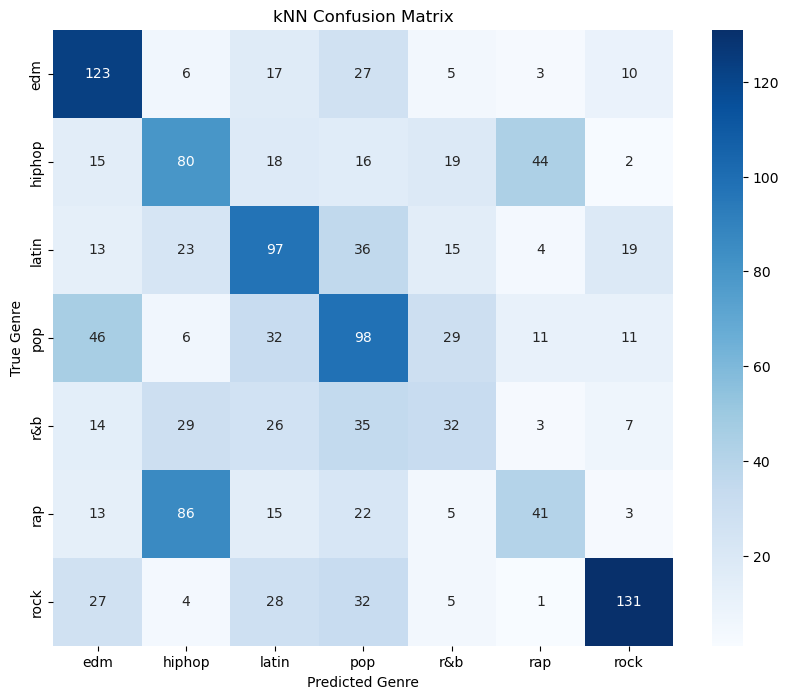

In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

genre_labels = label_encoder.classes_

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred, average='macro')

recall = recall_score(y_test, y_pred, average='macro')

f1 = f1_score(y_test, y_pred, average='macro')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=genre_labels,
    yticklabels=genre_labels
)

plt.title("kNN Confusion Matrix")
plt.xlabel("Predicted Genre")
plt.ylabel("True Genre")

plt.show()




Now let's try a couple of different k values...and plot the differences 

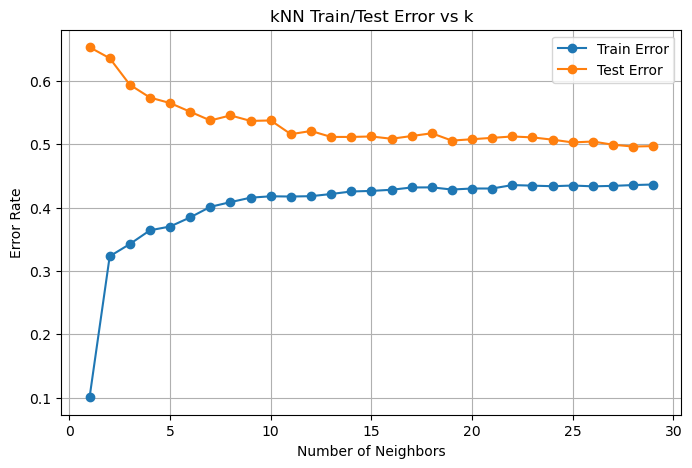

In [9]:

k_values = range(1, 30)

train_errors = []
test_errors = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    train_pred = knn.predict(X_train)
    test_pred = knn.predict(X_test)

    train_error = 1 - accuracy_score(y_train, train_pred)
    test_error = 1 - accuracy_score(y_test, test_pred)

    train_errors.append(train_error)
    test_errors.append(test_error)

plt.figure(figsize=(8, 5))
plt.plot(k_values, train_errors, marker='o', label='Train Error')
plt.plot(k_values, test_errors, marker='o', label='Test Error')

plt.title("kNN Train/Test Error vs k")
plt.xlabel("Number of Neighbors")
plt.ylabel("Error Rate")
plt.legend()
plt.grid(True)
plt.show()

We can see from this graph the for small k values kNN memorizes training data since we have near zero train error but high test error, leading to high variance and overfitting. For larger k values we get closer train and test errors meaning the model is able to correctly guess the genre more often but our test error is plateauing around k = 20 and above, signaling high bias and slight underfitting. The sweet spot appears to be somewhere between k = 10 and 15.